##### Cross-Sectional Market Neutral Strategy >> last 1m/5m/15m/30m/2h/4h OB-Microstructure Scoring System >> H-Correlated + De-Correlated Asset Collection Hypothesis 
<code>Discretionary-Capacity</code>

import random
import time
import numpy as np
import math
import ccxt
from pprint import pprint
import matplotlib.pyplot as plt
import os
import sys
import importlib

In [63]:
import random
import time
import numpy as np
import math
import ccxt
from pprint import pprint
import matplotlib.pyplot as plt
import os
import sys
import importlib
import requests

In [64]:
current_dir = os.getcwd()
sys.path.append(os.path.join(current_dir, '../'))

In [65]:
import data_retrieve.main_data
import data_retrieve.utils.universe 
import data_retrieve.utils.collect_data

importlib.reload(data_retrieve.main_data)
importlib.reload(data_retrieve.utils.universe)
importlib.reload(data_retrieve.utils.collect_data)

from data_retrieve.main_data import *
from data_retrieve.utils.universe import __fixed_exchange_universe__, __fixed_token_universe__, __fixed_top_liquids__
from data_retrieve.utils.collect_data import *

In [66]:
exchanges = __fixed_exchange_universe__()
fixed_tokens = __fixed_top_liquids__()

print('tokens:')
print(fixed_tokens)

print()

print('exchanges:')
print(exchanges)

tokens:
['BTC/USDT', 'ETH/USDT', 'SOL/USDT', 'AVAX/USDT', 'ATOM/USDT', 'TRX/USDT', 'XRP/USDT', 'DOGE/USDT', 'ADA/USDT', 'HYPE/USDT', 'PURR/USDT', 'MATIC/USDT', 'LINK/USDT', 'DOT/USDT', 'BLUR/USDT', 'EIGEN/USDT', 'CRV/USDT', 'APE/USDT']

exchanges:
['binance', 'bybit', 'okx', 'bitget', 'gateio', 'deribit', 'bitfinex', 'kucoinfutures', 'bingx', 'phemex']


In [67]:
_timeframe_trend = '30m'
_timeframe_intrabar = '1m'
_timeframe_trend_long = '2h'
_timeframe_trend_15min = '15m'
_timeframe_trend_ob_3min = '3m'

_limit = 500

In [68]:
benchmark_token = 'BTC/USDC:USDC'

In [69]:
ft_script = time.time()

In [70]:
# Case 1: multiple exchanges, single token
provider = CCXTDataProvider(exchanges=exchanges[:2], timeframe=_timeframe_trend, limit=_limit)
df_multi_ex = provider.fetch_multi(tokens=[fixed_tokens[0]])
display(df_multi_ex.head())

open      high       low     close  \
token            datetime                                                      
BTC/USDT@binance 2025-11-26 06:00:00  87519.54  87706.00  87409.78  87613.54   
                 2025-11-26 06:30:00  87613.55  87889.00  87465.00  87794.00   
                 2025-11-26 07:00:00  87794.00  87887.99  87698.25  87799.99   
                 2025-11-26 07:30:00  87800.00  87970.00  87709.26  87935.05   
                 2025-11-26 08:00:00  87935.05  87941.58  87530.33  87557.31   

                                         volume  
token            datetime                        
BTC/USDT@binance 2025-11-26 06:00:00  351.20712  
                 2025-11-26 06:30:00  216.54841  
                 2025-11-26 07:00:00  176.80448  
                 2025-11-26 07:30:00  169.55566  
                 2025-11-26 08:00:00  180.78200

Perps-Market-Retrieval

In [71]:
import data_retrieve.utils.universe
importlib.reload(data_retrieve.utils.universe)
from data_retrieve.utils.universe import __vol_liq_universe_selection__, __vol_liq_universe_selection_v2__, __vol_corr_universe_selection_v2__

Hyperliquid:

In [72]:
# Initialize exchange
exchange = ccxt.hyperliquid({
    "options": {
        "defaultType": "future",  # ensure futures are loaded
    }
})

# Load markets
markets = exchange.load_markets()

# Filter only futures pairs
futures_pairs = [symbol for symbol, market in markets.items() if not market["future"]]
futures_pairs = [symbol for symbol in futures_pairs if symbol.split('/')[-1] == 'USDC:USDC']

print(f"Total futures pairs: {len(futures_pairs)}")
print(futures_pairs)

Total futures pairs: 221
['BTC/USDC:USDC', 'ETH/USDC:USDC', 'ATOM/USDC:USDC', 'MATIC/USDC:USDC', 'DYDX/USDC:USDC', 'SOL/USDC:USDC', 'AVAX/USDC:USDC', 'BNB/USDC:USDC', 'APE/USDC:USDC', 'OP/USDC:USDC', 'LTC/USDC:USDC', 'ARB/USDC:USDC', 'DOGE/USDC:USDC', 'INJ/USDC:USDC', 'SUI/USDC:USDC', 'KPEPE/USDC:USDC', 'CRV/USDC:USDC', 'LDO/USDC:USDC', 'LINK/USDC:USDC', 'STX/USDC:USDC', 'RNDR/USDC:USDC', 'CFX/USDC:USDC', 'FTM/USDC:USDC', 'GMX/USDC:USDC', 'SNX/USDC:USDC', 'XRP/USDC:USDC', 'BCH/USDC:USDC', 'APT/USDC:USDC', 'AAVE/USDC:USDC', 'COMP/USDC:USDC', 'MKR/USDC:USDC', 'WLD/USDC:USDC', 'FXS/USDC:USDC', 'HPOS/USDC:USDC', 'RLB/USDC:USDC', 'UNIBOT/USDC:USDC', 'YGG/USDC:USDC', 'TRX/USDC:USDC', 'KSHIB/USDC:USDC', 'UNI/USDC:USDC', 'SEI/USDC:USDC', 'RUNE/USDC:USDC', 'OX/USDC:USDC', 'FRIEND/USDC:USDC', 'SHIA/USDC:USDC', 'CYBER/USDC:USDC', 'ZRO/USDC:USDC', 'BLZ/USDC:USDC', 'DOT/USDC:USDC', 'BANANA/USDC:USDC', 'TRB/USDC:USDC', 'FTT/USDC:USDC', 'LOOM/USDC:USDC', 'OGN/USDC:USDC', 'RDNT/USDC:USDC', 'ARK/USDC:U

Lighter:

Zero Trading Fees for Retail-Flow (Maker/Taker) - Lighter Points Distribution based on PnL of the strategy NOT solely linked on the volume provided

In [73]:
def get_lighter_traded_tokens():
    url = "https://mainnet.zklighter.elliot.ai/api/v1/orderBooks"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()

        # The response contains a "order_books" list
        if "order_books" in data:
            print(f"Found {len(data['order_books'])} markets in lighter.xyz")
            
            # Extract and print just the symbols
            symbols = [market['symbol'] for market in data['order_books']]            
            return symbols
        
        else:
            print("Unexpected JSON structure:", data.keys())

    except Exception as e:
        print(f"Error fetching data: {e}")

lighter_perps_token = get_lighter_traded_tokens()

Found 118 markets in lighter.xyz


INTERSECTION_UNIVERSE_SELECTION

In [74]:
futures_pairs = [symbol for symbol in futures_pairs if symbol.split('/')[0] in lighter_perps_token]
print('Hyperliquid/Lighter-Intersection-Pairs: ', len(futures_pairs))

Hyperliquid/Lighter-Intersection-Pairs:  85


In [75]:
fixed_tokens = futures_pairs.copy()
print(fixed_tokens[:]) 

['BTC/USDC:USDC', 'ETH/USDC:USDC', 'DYDX/USDC:USDC', 'SOL/USDC:USDC', 'AVAX/USDC:USDC', 'BNB/USDC:USDC', 'OP/USDC:USDC', 'LTC/USDC:USDC', 'ARB/USDC:USDC', 'DOGE/USDC:USDC', 'SUI/USDC:USDC', 'CRV/USDC:USDC', 'LDO/USDC:USDC', 'LINK/USDC:USDC', 'GMX/USDC:USDC', 'XRP/USDC:USDC', 'BCH/USDC:USDC', 'APT/USDC:USDC', 'AAVE/USDC:USDC', 'MKR/USDC:USDC', 'WLD/USDC:USDC', 'TRX/USDC:USDC', 'UNI/USDC:USDC', 'SEI/USDC:USDC', 'ZRO/USDC:USDC', 'DOT/USDC:USDC', 'TIA/USDC:USDC', 'ADA/USDC:USDC', 'TON/USDC:USDC', 'PENDLE/USDC:USDC', 'NEAR/USDC:USDC', 'FIL/USDC:USDC', 'PYTH/USDC:USDC', 'JUP/USDC:USDC', 'WIF/USDC:USDC', 'ONDO/USDC:USDC', 'STRK/USDC:USDC', 'TAO/USDC:USDC', 'ETHFI/USDC:USDC', 'ENA/USDC:USDC', 'MNT/USDC:USDC', 'HBAR/USDC:USDC', 'POPCAT/USDC:USDC', 'EIGEN/USDC:USDC', 'ZK/USDC:USDC', 'POL/USDC:USDC', 'GRASS/USDC:USDC', 'HYPE/USDC:USDC', 'VIRTUAL/USDC:USDC', 'PENGU/USDC:USDC', 'FARTCOIN/USDC:USDC', 'AI16Z/USDC:USDC', 'SPX/USDC:USDC', 'S/USDC:USDC', 'MORPHO/USDC:USDC', 'TRUMP/USDC:USDC', 'VVV/USDC:

-----

<code>Server-Rolling-OB</code>

In [76]:
import src.scp
importlib.reload(src.scp)
from src.scp import get_rolling_ob_aws
get_rolling_ob_aws()

working-dir:  c:\Users\Alik\Desktop\M_1_year\Liquid-Net\Microstructure-LLM-Trade-Engine
working-dir:  c:\Users\Alik\Desktop\M_1_year\Liquid-Net\Microstructure-LLM-Trade-Engine
Copying orderbook_data/ from AWS...
Copying rolling_ob.log from AWS...


In [77]:
rollling_ob_path = 'quanta/orderbook_data/rolling_ob.pkl'

In [78]:
try:
    master_ob = pd.read_pickle(rollling_ob_path).loc['hyperliquid']
    print("Loaded with pandas")
    display(master_ob.head(3))
except Exception as e:
    print("Pandas load failed:", e)

Loaded with pandas


size
token        datetime                         side price         
0G/USDC:USDC 2025-12-06 11:31:09.513000+00:00 ask  1.0173  1000.0
                                                   1.0176  1963.0
                                                   1.0179  2069.0

In [79]:
_dates = list(set([date for date, _, _ in master_ob.loc[benchmark_token].index]))
_dates = sorted(_dates)
print('#Dates: ', len(_dates)) #1680
print(_dates[-1])

#Dates:  80
2025-12-06 15:27:04.897000+00:00


MASTER_OB - prune

In [80]:
master_token_list = set([name for name, _, _, _ in master_ob.index])
fixed_tokens = [token for token in master_token_list if token in fixed_tokens]
print('Pruned-Fixed-Tokens: ', len(fixed_tokens))

Pruned-Fixed-Tokens:  82


In [81]:
t_exchange = 'hyperliquid'

In [82]:
ft = time.time()
## FIX: Intrabar ~ 1min will have more information than 30min (30 - 1min discretes)
provider = CCXTDataProvider(exchanges=[t_exchange], timeframe=_timeframe_intrabar, limit=_limit)
df_multi_token_all_1min = provider.fetch_multi(exchange=t_exchange, tokens=futures_pairs)
lt = time.time()

print('time-taken (entire-universe): ', (lt - ft)/60, ' mins')

time-taken (entire-universe):  0.7809107383092244  mins


##### Linear/Non-Linear OBM-based Scoring > Universe Selection

In [83]:
# Case 2: single exchange, multiple tokens
print('exchange-selected: ', t_exchange)

print('_timeframe_intrabar: ', _timeframe_intrabar)
provider = CCXTDataProvider(exchanges=[t_exchange], timeframe=_timeframe_intrabar, limit=_limit)
df_multi_token_1min = provider.fetch_multi(exchange=t_exchange, tokens=fixed_tokens)

display(df_multi_token_1min.head())

print('_timeframe_trend_ob_3min: ', _timeframe_trend_ob_3min)
provider = CCXTDataProvider(exchanges=[t_exchange], timeframe=_timeframe_trend_ob_3min, limit=_limit)
df_multi_token_3min = provider.fetch_multi(exchange=t_exchange, tokens=fixed_tokens)

display(df_multi_token_3min.head())

print('_timeframe_trend_15min: ', _timeframe_trend_15min)
provider = CCXTDataProvider(exchanges=[t_exchange], timeframe=_timeframe_trend_15min, limit=_limit)
df_multi_token_15min = provider.fetch_multi(exchange=t_exchange, tokens=fixed_tokens)

display(df_multi_token_15min.head())

print('_timeframe_trend_long: ', _timeframe_trend_long)
provider = CCXTDataProvider(exchanges=[t_exchange], timeframe=_timeframe_trend_long, limit=_limit)
df_multi_token_2h = provider.fetch_multi(exchange=t_exchange, tokens=fixed_tokens)

display(df_multi_token_2h.head())

print()


exchange-selected:  hyperliquid
_timeframe_intrabar:  1m
Failed hyperliquid:HBAR/USDC:USDC -> hyperliquid POST https://api.hyperliquid.xyz/info 429 Too Many Requests null
Failed hyperliquid:WLFI/USDC:USDC -> hyperliquid POST https://api.hyperliquid.xyz/info 429 Too Many Requests null
Failed hyperliquid:TAO/USDC:USDC -> hyperliquid POST https://api.hyperliquid.xyz/info 429 Too Many Requests null


open    high     low   close  volume
token        datetime                                                   
0G/USDC:USDC 2025-12-06 07:12:00  1.0329  1.0329  1.0329  1.0329     0.0
             2025-12-06 07:13:00  1.0322  1.0325  1.0322  1.0325   170.0
             2025-12-06 07:14:00  1.0325  1.0325  1.0325  1.0325     0.0
             2025-12-06 07:15:00  1.0325  1.0325  1.0325  1.0325     0.0
             2025-12-06 07:16:00  1.0334  1.0334  1.0334  1.0334    16.0

_timeframe_trend_ob_3min:  3m
Failed hyperliquid:DOT/USDC:USDC -> hyperliquid POST https://api.hyperliquid.xyz/info 429 Too Many Requests null
Failed hyperliquid:SPX/USDC:USDC -> hyperliquid POST https://api.hyperliquid.xyz/info 429 Too Many Requests null
Failed hyperliquid:PUMP/USDC:USDC -> hyperliquid POST https://api.hyperliquid.xyz/info 429 Too Many Requests null


open    high     low   close  volume
token        datetime                                                   
0G/USDC:USDC 2025-12-05 14:33:00  1.0882  1.0882  1.0862  1.0864   190.0
             2025-12-05 14:36:00  1.0861  1.0861  1.0847  1.0852   152.0
             2025-12-05 14:39:00  1.0829  1.0829  1.0749  1.0749  1733.0
             2025-12-05 14:42:00  1.0796  1.0796  1.0794  1.0794    53.0
             2025-12-05 14:45:00  1.0781  1.0801  1.0778  1.0782   138.0

_timeframe_trend_15min:  15m


open    high     low   close  volume
token        datetime                                                   
0G/USDC:USDC 2025-12-01 10:45:00  1.0856  1.0881  1.0848  1.0863   759.0
             2025-12-01 11:00:00  1.0865  1.0865  1.0753  1.0753  1286.0
             2025-12-01 11:15:00  1.0763  1.0795  1.0743  1.0781  3144.0
             2025-12-01 11:30:00  1.0787  1.0787  1.0740  1.0758  1472.0
             2025-12-01 11:45:00  1.0777  1.0801  1.0770  1.0778  6259.0

_timeframe_trend_long:  2h


open    high     low   close   volume
token        datetime                                                    
0G/USDC:USDC 2025-10-26 00:00:00  1.7533  1.7570  1.7388  1.7514  84982.0
             2025-10-26 02:00:00  1.7520  1.7604  1.7207  1.7269  94854.0
             2025-10-26 04:00:00  1.7266  1.7463  1.7252  1.7434  65134.0
             2025-10-26 06:00:00  1.7433  1.7469  1.7222  1.7354  40428.0
             2025-10-26 08:00:00  1.7374  1.7511  1.7308  1.7483  51945.0

API/FAIL-Pruning (3min)

In [84]:
min3_token = list(set([token for token, _ in df_multi_token_3min.index]))
fixed_tokens = [token for token in fixed_tokens if token in min3_token]
print('pruned2-token-size: ', len(fixed_tokens))

pruned2-token-size:  79


OHLCV-DATA

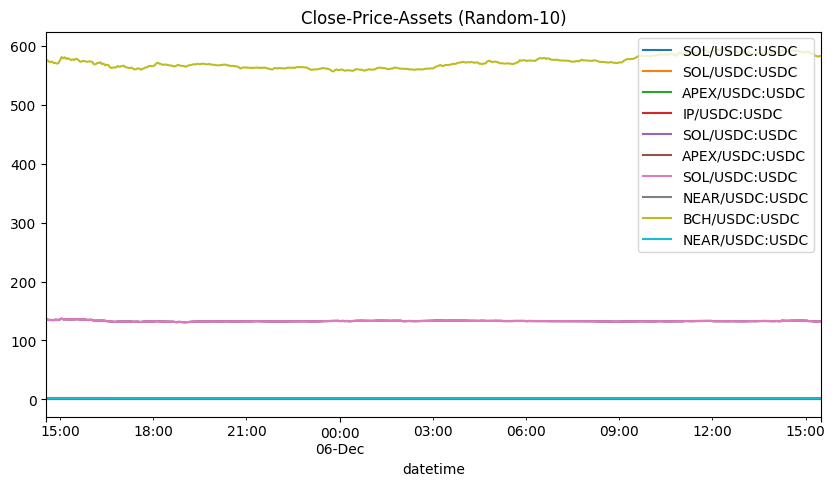

In [85]:
fig, axs = plt.subplots(1, 1, figsize=(10, 5))

for token in np.array(fixed_tokens)[np.random.randint(0, 9, size=(10,)).tolist()]:
    df_multi_token_3min.loc[token].close.plot(ax=axs, label=token)

plt.legend()
plt.title('Close-Price-Assets (Random-10)')
plt.show()

In [86]:
from engine.utils.features import *

In [87]:
s_window=20
MAX_BACK=80

In [88]:
df_multi_token_3min = df_multi_token_3min.groupby(level=0).tail(MAX_BACK)
df_multi_token_3min.index = df_multi_token_3min.index.set_levels(df_multi_token_3min.index.levels[1].tz_localize('UTC'), level=1)

In [89]:
target_token = fixed_tokens[0]
print('fixed_tokens: ', target_token)

fixed_tokens:  SOL/USDC:USDC


In [90]:
master_ob_benchmark = master_ob.loc[benchmark_token]
master_ob_target = master_ob.loc[target_token]

Current-Timestamp <code>L2-OB</code> Snapshot

In [91]:
ob = OrderBookProvider(exchanges=[t_exchange], depth=100)
ob_l1_df = ob.fetch_multi(exchange=t_exchange, tokens=fixed_tokens, level='L1')
ob_l2_df = ob.fetch_multi(exchange=t_exchange, tokens=fixed_tokens, level='L2')

asks_btc = ob_l2_df.loc[(benchmark_token, slice(None), 'ask', slice(None), slice(None))].reset_index().drop('datetime', axis=1)
bids_btc = ob_l2_df.loc[(benchmark_token, slice(None), 'bid', slice(None), slice(None))].reset_index().drop('datetime', axis=1)
bids_btc = bids_btc.sort_values('price', ascending=False)

asks = ob_l2_df.loc[(target_token, slice(None), 'ask', slice(None), slice(None))].reset_index().drop('datetime', axis=1)
bids = ob_l2_df.loc[(target_token, slice(None), 'bid', slice(None), slice(None))].reset_index().drop('datetime', axis=1)
bids = bids.sort_values('price', ascending=False)

print('OB-Depth: ', len(asks))

asks_btc['cum_size'] = asks_btc['size'].cumsum()
bids_btc['cum_size'] = bids_btc['size'].cumsum()

asks['cum_size'] = asks['size'].cumsum()
bids['cum_size'] = bids['size'].cumsum()


OB-Depth:  20


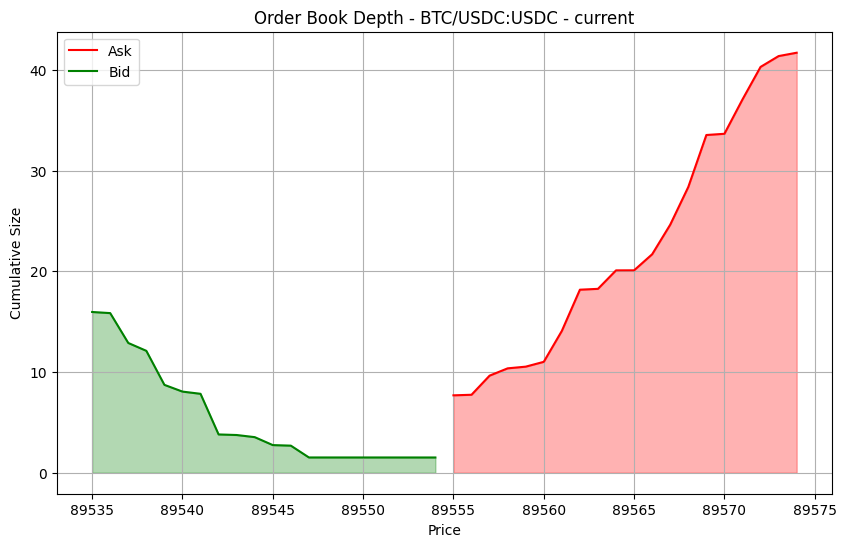

In [92]:
plt.figure(figsize=(10,6))

# Plot cumulative depth
plt.plot(asks_btc['price'], asks_btc['cum_size'], color='red', label='Ask')
plt.fill_between(asks_btc['price'], asks_btc['cum_size'], 0, color='red', alpha=0.3)

plt.plot(bids_btc['price'], bids_btc['cum_size'], color='green', label='Bid')
plt.fill_between(bids_btc['price'], bids_btc['cum_size'], 0, color='green', alpha=0.3)

plt.xlabel('Price')
plt.ylabel('Cumulative Size')
plt.title(f'Order Book Depth - {benchmark_token} - current')
plt.legend()
plt.grid(True)
plt.show()

In [93]:
display(master_ob_benchmark.head(3))

print()

display(master_ob.head(3))

size
datetime                         side price           
2025-12-06 11:30:05.126000+00:00 ask  89534.0  0.00549
                                      89535.0  0.00025
                                      89536.0  0.00013

size
token        datetime                         side price         
0G/USDC:USDC 2025-12-06 11:31:09.513000+00:00 ask  1.0173  1000.0
                                                   1.0176  1963.0
                                                   1.0179  2069.0

In [94]:
ob_roll = OrderBookRollingFeatures(master_ob_benchmark)
features_benchmark_ob = ob_roll.extract_all_features()

ob_roll = OrderBookRollingFeatures(master_ob_target)
features_target_ob = ob_roll.extract_all_features()

feature_col = features_benchmark_ob.columns

print('columns: ', feature_col, len(features_benchmark_ob.columns))

print(' -- BENCHMARK-FEATURE -- ')
display(features_benchmark_ob.head(2))

print()
print(' --- MASTER-TABLE-OB --- ')
print()

features_roll_ob_list = []
for token in fixed_tokens:
    master_ob_token = master_ob.loc[token]
    ob_roll = OrderBookRollingFeatures(master_ob_token)
    features_roll_ob_list.append(ob_roll.extract_all_features())

features_roll_ob = pd.concat(features_roll_ob_list, keys=fixed_tokens)

print(' -- MULTIINDEX-FEATURE -- ')
display(features_roll_ob.head(2))


columns:  Index(['OBI_top5', 'slope_bid', 'slope_ask', 'Microprice_drift', 'RelSpread',
       'DepthConc_top3', 'OBI_top5_5m_vs_30m', 'OBI_top5_30m_vs_2h',
       'OBI_top5_last5m', 'OBI_top5_last30m', 'OBI_top5_last2h',
       'OBI_top5_last5m_vs_30m', 'OBI_top5_last30m_vs_2h',
       'slope_bid_5m_vs_30m', 'slope_bid_30m_vs_2h', 'slope_bid_last5m',
       'slope_bid_last30m', 'slope_bid_last2h', 'slope_bid_last5m_vs_30m',
       'slope_bid_last30m_vs_2h', 'slope_ask_5m_vs_30m', 'slope_ask_30m_vs_2h',
       'slope_ask_last5m', 'slope_ask_last30m', 'slope_ask_last2h',
       'slope_ask_last5m_vs_30m', 'slope_ask_last30m_vs_2h',
       'Microprice_drift_5m_vs_30m', 'Microprice_drift_30m_vs_2h',
       'Microprice_drift_last5m', 'Microprice_drift_last30m',
       'Microprice_drift_last2h', 'Microprice_drift_last5m_vs_30m',
       'Microprice_drift_last30m_vs_2h', 'RelSpread_5m_vs_30m',
       'RelSpread_30m_vs_2h', 'RelSpread_last5m', 'RelSpread_last30m',
       'RelSpread_last2h', 'Re

,OBI_top5,slope_bid,slope_ask,Microprice_drift,RelSpread,DepthConc_top3,OBI_top5_5m_vs_30m,OBI_top5_30m_vs_2h,OBI_top5_last5m,OBI_top5_last30m,...,RelSpread_last2h,RelSpread_last5m_vs_30m,RelSpread_last30m_vs_2h,DepthConc_top3_5m_vs_30m,DepthConc_top3_30m_vs_2h,DepthConc_top3_last5m,DepthConc_top3_last30m,DepthConc_top3_last2h,DepthConc_top3_last5m_vs_30m,DepthConc_top3_last30m_vs_2h
2025-12-06 11:30:05.126000+00:00,0.999210,-19526.011533,770.289310,0.000006,0.000011,0.597213,0.0,0.0,0.354661,-0.254415,...,0.000012,0.000004,3.106614e-07,0.0,0.0,0.163116,0.231173,0.233205,-0.068057,-0.002032
2025-12-06 11:33:04.877000+00:00,0.998185,-14276.646730,319.031994,0.000006,0.000011,0.344042,0.0,0.0,0.354661,-0.254415,...,0.000012,0.000004,3.106614e-07,0.0,0.0,0.163116,0.231173,0.233205,-0.068057,-0.002032



 --- MASTER-TABLE-OB --- 

 -- MULTIINDEX-FEATURE -- 


OBI_top5    slope_bid  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00 -0.464825  5280.633502   
              2025-12-06 11:33:05.986000+00:00  0.047733  2150.865189   

                                                  slope_ask  Microprice_drift  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00   567.939317         -0.000037   
              2025-12-06 11:33:05.986000+00:00  4123.328346          0.000031   

                                                RelSpread  DepthConc_top3  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00   0.000075        0.089163   
              2025-12-06 11:33:05.986000+00:00   0.000075        0.064316   

                                                OBI_top5_5m_vs_30m  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                 0.0   
              2025-12-06 11:33:05.986000+00:00                 0.0   

                                                OBI_top5_30m_vs_2h  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                 0.0   
              2025-12-06 11:33:05.986000+00:00                 0.0   

                                                OBI_top5_last5m  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00         0.540424   
              2025-12-06 11:33:05.986000+00:00         0.540424   

                                                OBI_top5_last30m  ...  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00          0.176211  ...   
              2025-12-06 11:33:05.986000+00:00          0.176211  ...   

                                                RelSpread_last2h  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00          0.000081   
              2025-12-06 11:33:05.986000+00:00          0.000081   

                                                RelSpread_last5m_vs_30m  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00             3.022497e-07   
              2025-12-06 11:33:05.986000+00:00             3.022497e-07   

                                                RelSpread_last30m_vs_2h  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                -0.000005   
              2025-12-06 11:33:05.986000+00:00                -0.000005   

                                                DepthConc_top3_5m_vs_30m  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                       0.0   
              2025-12-06 11:33:05.986000+00:00                       0.0   

                                                DepthConc_top3_30m_vs_2h  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                       0.0   
              2025-12-06 11:33:05.986000+00:00                       0.0   

                                                DepthConc_top3_last5m  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00               0.093672   
              2025-12-06 11:33:05.986000+00:00               0.093672   

                                                DepthConc_top3_last30m  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                0.077707   
              2025-12-06 11:33:05.986000+00:00                0.077707   

                                                DepthConc_top3_last2h  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00               0.074789   
              2025-12-06 11:33:05.986000+00:00               0.074789   

                                                DepthConc_top3_last5m_vs_30m  \
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                      0.015965   
              2025-12-06 11:33:05.986000+00:00                      0.015965   

                                                DepthConc_top3_last30m_vs_2h  
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                      0.002918  
              2025-12-06 11:33:05.986000+00:00                      0.002918  

[2 rows x 48 columns]

In [95]:
import engine.utils.features
importlib.reload(engine.utils.features)
from engine.utils.features import *

In [96]:
fmtf_list = []
ft = time.time()
for token in fixed_tokens:
    fmtf = FeatureEngineMTF(df_multi_token_3min.loc[token], token=token) ## 3min-Discretized/refined
    fmtf_list.append(fmtf.calculate_features(frame='3min'))
fmtf_df_3min = pd.concat(fmtf_list, keys=fixed_tokens)
display(fmtf_df_3min.head(3))
lt = time.time()

print('feature-processing-time: ', (lt - ft)/60, ' mins')

roc        vwap  price_vs_vwap  \
              timestamp                                                        
SOL/USDC:USDC 2025-12-06 11:33:00+00:00  0.000000         NaN            NaN   
              2025-12-06 11:36:00+00:00 -0.000451  133.046027      -0.066027   
              2025-12-06 11:39:00+00:00 -0.000075  133.043108      -0.013108   

                                          vol_acc  volatility  
              timestamp                                        
SOL/USDC:USDC 2025-12-06 11:33:00+00:00  1.000000    0.000000  
              2025-12-06 11:36:00+00:00  0.210323         NaN  
              2025-12-06 11:39:00+00:00  0.243060    0.000585

feature-processing-time:  0.33810238043467206  mins


<code>Feature-Engineering</code>

Drift/Relative-Deviation/Last-Window-Average

In [97]:
# Drift/Evolution (first 6 features)
drift_cols = ['OBI_top5', 'slope_bid', 'slope_ask', 
              'Microprice_drift', 'RelSpread', 'DepthConc_top3']

df_drift_benchmark = features_benchmark_ob[drift_cols]
df_drift_eth = features_target_ob[drift_cols]
df_drift_sol = features_roll_ob.loc['SOL/USDC:USDC'][drift_cols]

# Deviation/Comparison
dev_cols = [c for c in features_benchmark_ob.columns if "_5m_vs_" in c or "_30m_vs_" in c]
df_dev_benchmark = features_benchmark_ob[dev_cols]

# Last-window averages
last_cols = [c for c in features_benchmark_ob.columns if "last" in c]
df_benchmark_last = features_benchmark_ob[last_cols]  # you said only need one DF here

Feature-Group (Value/Volatility/Momentum etc)

In [98]:
print('OB-microstructure-features: ', list(feature_col))
print('Price/Vol: ',  list(df_multi_token_3min.columns))
print('Agg-Features: ', list(fmtf_df_3min.loc['BTC/USDC:USDC'].columns))

eng_features = list(feature_col) + list(fmtf_df_3min.loc['BTC/USDC:USDC'].columns)

OB-microstructure-features:  ['OBI_top5', 'slope_bid', 'slope_ask', 'Microprice_drift', 'RelSpread', 'DepthConc_top3', 'OBI_top5_5m_vs_30m', 'OBI_top5_30m_vs_2h', 'OBI_top5_last5m', 'OBI_top5_last30m', 'OBI_top5_last2h', 'OBI_top5_last5m_vs_30m', 'OBI_top5_last30m_vs_2h', 'slope_bid_5m_vs_30m', 'slope_bid_30m_vs_2h', 'slope_bid_last5m', 'slope_bid_last30m', 'slope_bid_last2h', 'slope_bid_last5m_vs_30m', 'slope_bid_last30m_vs_2h', 'slope_ask_5m_vs_30m', 'slope_ask_30m_vs_2h', 'slope_ask_last5m', 'slope_ask_last30m', 'slope_ask_last2h', 'slope_ask_last5m_vs_30m', 'slope_ask_last30m_vs_2h', 'Microprice_drift_5m_vs_30m', 'Microprice_drift_30m_vs_2h', 'Microprice_drift_last5m', 'Microprice_drift_last30m', 'Microprice_drift_last2h', 'Microprice_drift_last5m_vs_30m', 'Microprice_drift_last30m_vs_2h', 'RelSpread_5m_vs_30m', 'RelSpread_30m_vs_2h', 'RelSpread_last5m', 'RelSpread_last30m', 'RelSpread_last2h', 'RelSpread_last5m_vs_30m', 'RelSpread_last30m_vs_2h', 'DepthConc_top3_5m_vs_30m', 'Depth

In [99]:
feature_groups = {
    # BULLISH PRESSURE (Positive Correlation)
    'group_obi': [
        'OBI_top5', 'OBI_top5_last5m', 'OBI_top5_last30m', 'OBI_top5_last2h',
        'OBI_top5_5m_vs_30m', 'OBI_top5_30m_vs_2h',
        'OBI_top5_last5m_vs_30m', 'OBI_top5_last30m_vs_2h'
    ],

    # SUPPORT STRENGTH (Positive Correlation)
    'group_bid_slope': [
        'slope_bid', 'slope_bid_last5m', 'slope_bid_last30m', 'slope_bid_last2h',
        'slope_bid_5m_vs_30m', 'slope_bid_30m_vs_2h',
        'slope_bid_last5m_vs_30m', 'slope_bid_last30m_vs_2h'
    ],

    # RESISTANCE STRENGTH (Negative Correlation - Flip Sign)
    'group_ask_slope': [
        'slope_ask', 'slope_ask_last5m', 'slope_ask_last30m', 'slope_ask_last2h',
        'slope_ask_5m_vs_30m', 'slope_ask_30m_vs_2h',
        'slope_ask_last5m_vs_30m', 'slope_ask_last30m_vs_2h'
    ],

    # MICRO TREND (Positive Correlation)
    'group_micro_drift': [
        'Microprice_drift', 'Microprice_drift_last5m', 'Microprice_drift_last30m', 
        'Microprice_drift_last2h', 'Microprice_drift_5m_vs_30m', 
        'Microprice_drift_30m_vs_2h', 'Microprice_drift_last5m_vs_30m', 
        'Microprice_drift_last30m_vs_2h'
    ],

    # FRICTION/LIQUIDITY (Negative Correlation - Flip Sign)
    'group_spread': [
        'RelSpread', 'RelSpread_last5m', 'RelSpread_last30m', 'RelSpread_last2h',
        'RelSpread_5m_vs_30m', 'RelSpread_30m_vs_2h', 
        'RelSpread_last5m_vs_30m', 'RelSpread_last30m_vs_2h'
    ],

    # BOOK STABILITY (Negative Correlation - Flip Sign usually)
    'group_depth_conc': [
        'DepthConc_top3', 'DepthConc_top3_last5m', 'DepthConc_top3_last30m', 
        'DepthConc_top3_last2h', 'DepthConc_top3_5m_vs_30m', 
        'DepthConc_top3_30m_vs_2h', 'DepthConc_top3_last5m_vs_30m', 
        'DepthConc_top3_last30m_vs_2h'
    ],

    # AGGREGATE PRICE MOMENTUM (Positive Correlation)
    'group_price_mom': [
        'roc', 'price_vs_vwap'
    ],

    # ACTIVITY (Positive Correlation)
    'group_activity': [
        'vol_acc', 'volatility'
    ]
}

ignored_features = ['open', 'high', 'low', 'close', 'volume', 'vwap']

OB-Drift

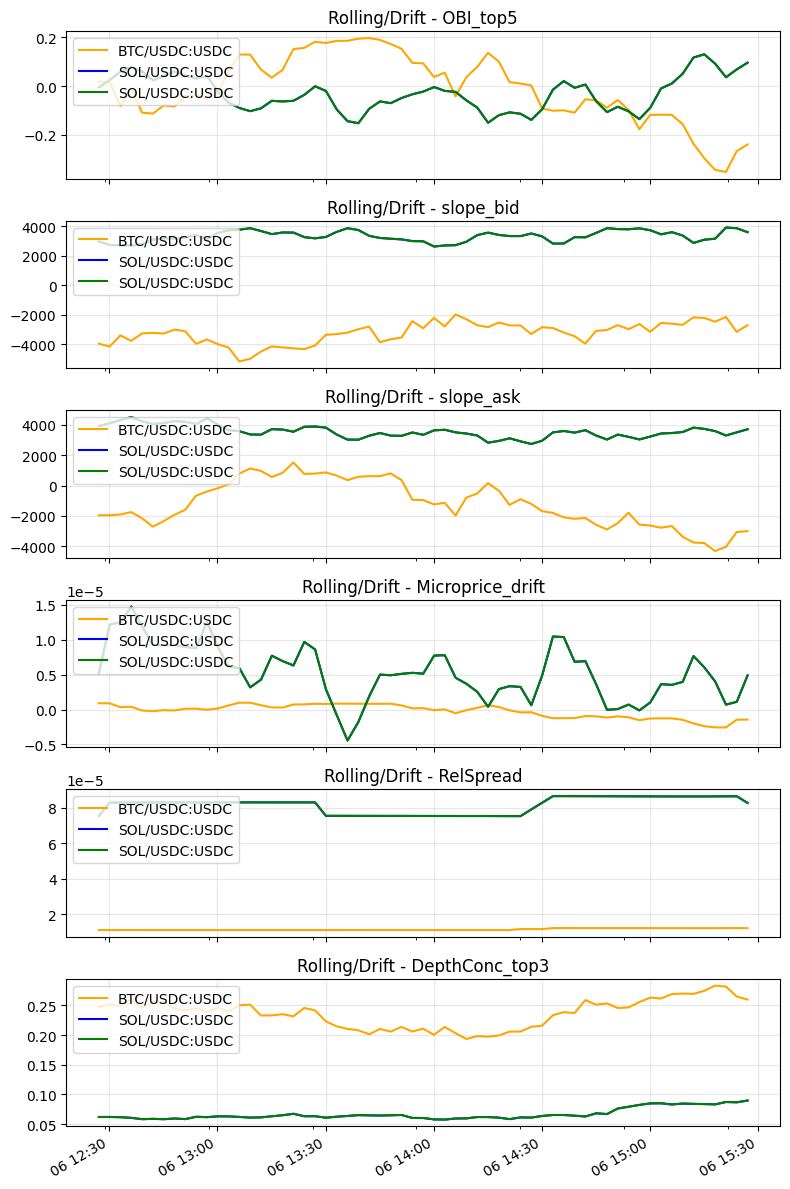

In [100]:
# Take the first 6 drift-related features
drift_cols = list(feature_col[:6])

fig, axs = plt.subplots(6, 1, figsize=(8, 12), sharex=True)

for i, col in enumerate(drift_cols):
    df_drift_benchmark[col].rolling(window=s_window).mean().plot(label=benchmark_token, color='orange', ax=axs[i])
    df_drift_eth[col].rolling(window=s_window).mean().plot(label=target_token, color='blue', ax=axs[i])
    df_drift_sol[col].rolling(window=s_window).mean().plot(label='SOL/USDC:USDC', color='green', ax=axs[i])
    
    axs[i].set_title(f'Rolling/Drift - {col}')
    axs[i].legend(loc="upper left")
    axs[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

-----

In [101]:
display(df_multi_token_1min.head(3))

print()

display(df_multi_token_3min.head(3))

print()

display(df_multi_token_15min.head(3))

print()

display(df_multi_token_2h.head(3))

open    high     low   close  volume
token        datetime                                                   
0G/USDC:USDC 2025-12-06 07:12:00  1.0329  1.0329  1.0329  1.0329     0.0
             2025-12-06 07:13:00  1.0322  1.0325  1.0322  1.0325   170.0
             2025-12-06 07:14:00  1.0325  1.0325  1.0325  1.0325     0.0

open    high     low   close  volume
token        datetime                                                         
0G/USDC:USDC 2025-12-06 11:33:00+00:00  1.0172  1.0190  1.0172  1.0190   972.0
             2025-12-06 11:36:00+00:00  1.0191  1.0191  1.0170  1.0170   349.0
             2025-12-06 11:39:00+00:00  1.0184  1.0196  1.0181  1.0181   454.0

open    high     low   close  volume
token        datetime                                                   
0G/USDC:USDC 2025-12-01 10:45:00  1.0856  1.0881  1.0848  1.0863   759.0
             2025-12-01 11:00:00  1.0865  1.0865  1.0753  1.0753  1286.0
             2025-12-01 11:15:00  1.0763  1.0795  1.0743  1.0781  3144.0

open    high     low   close   volume
token        datetime                                                    
0G/USDC:USDC 2025-10-26 00:00:00  1.7533  1.7570  1.7388  1.7514  84982.0
             2025-10-26 02:00:00  1.7520  1.7604  1.7207  1.7269  94854.0
             2025-10-26 04:00:00  1.7266  1.7463  1.7252  1.7434  65134.0

##### Scroing-Mechanism for relative-signal-Extraction (L/S MN Portfolio) 

Here is the **clean mathematical formulation** of the strategy, written concisely in Markdown code blocks.

---

#### **1. Feature Normalization (Cross-Sectional)**

For each feature ( f ) at time ( t ):

```markdown
med_f(t) = median_a( f(a, t) )
mad_f(t) = median_a( | f(a, t) - med_f(t) | )

z_f(a, t) = ( f(a, t) - med_f(t) ) / mad_f(t)
```

This makes each feature comparable across assets (unitless, robust).

---

#### **2. Group Score (Averaging Features)**

Each group ( g ) consists of a set of features ( f \in g ):

```markdown
G_g(a, t) = (1 / |g|) * Σ_{f ∈ g} z_f(a, t)
```

---

#### **3. Group Normalization (Cross-Sectional Again)**

Normalize each group score again so no group dominates the composite:

```markdown
med_g(t) = median_a( G_g(a, t) )
mad_g(t) = median_a( | G_g(a, t) - med_g(t) | )

Z_g(a, t) = ( G_g(a, t) - med_g(t) ) / mad_g(t)
```

---

#### **4. Composite Score (Equal-Weighted Across Groups)**

```markdown
S(a, t) = (1 / G) * Σ_{g=1..G} Z_g(a, t)
```

Where ( G ) = number of feature groups.

This is the **final predictive score**.

---

#### **5. Cross-Sectional Ranking**

Convert composite scores into percentiles:

```markdown
rank(a, t) = percentile_rank_a( S(a, t) )       # in [0,1]

score(a, t) = 2 * (rank(a, t) - 0.5)            # in [-1,1]
```

---

#### **6. Portfolio Construction (Top/Bottom Percentiles)**

Let

* ( L ) = top ( p_L ) percentile
* ( S ) = bottom ( p_S ) percentile.

```markdown
Longs(t)  = { a | score(a, t) ∈ top p_L }
Shorts(t) = { a | score(a, t) ∈ bottom p_S }

w(a, t) =
    +1 / |Longs|   if a ∈ Longs
    -1 / |Shorts|  if a ∈ Shorts
    0              otherwise
```

---

#### **7. Profit Mechanism (Expected Return)**

The alpha hypothesis is:

```markdown
E[ R(a, t+1) | S(a, t) ] = β * S(a, t)
```

Thus the long-short portfolio return is:

```markdown
E[ P(t+1) ] = β * ( mean_a∈L[S(a,t)]  -  mean_a∈S[S(a,t)] )
```

Since top scores > bottom scores:

```markdown
E[P(t+1)] > 0     if β > 0
```

This is why the strategy makes money.

---

#### **8. Market Neutrality**

```markdown
Σ_a w(a, t) ≈ 0
```

→ No exposure to market direction, only to **relative performance**.

---

If you want, I can produce a full LaTeX version, diagram, or a one-page “research note” version suitable for interviews.


In [102]:
def make_cross_sectional_scores_multiindex(
    df, # Expecting MultiIndex (Asset, Timestamp) or (Timestamp, Asset)
    feature_groups,
    inverse_groups=['group_ask_slope', 'group_spread', 'group_depth_conc'],
    asset_level='token',     
    time_level='timestamp_w',
    winsor_pct=0.01,
    rebalance_freq='30T',
    long_pct=0.10,
    short_pct=0.10
    ):
    
    """
    Optimized for MultiIndex Input (Token, Datetime).
    """
    
    # 1. Validation & Setup
    # Ensure input is actually MultiIndex
    if not isinstance(df.index, pd.MultiIndex):
        raise ValueError("Input DataFrame must be MultiIndex. Check your index.")

    # Sort index by timestamp to ensure time-series operations work (and unstack is clean)
    # We sort by the Time Level
    df = df.sort_index(level=time_level)

    # Flatten feature list
    all_features = sorted(list(set(sum(feature_groups.values(), []))))
    
    # Filter for existing columns only
    valid_features = [f for f in all_features if f in df.columns]
    if len(valid_features) < len(all_features):
        missing = set(all_features) - set(valid_features)
        print(f"Warning: Dropping missing features: {missing}")

    # 2. Reshaping (The MultiIndex Fix)
    # We want: Index = Timestamp, Columns = (Feature, Asset)
    # This creates a DataFrame where top column level is Feature, second is Asset
    try:
        pivot = df[valid_features].unstack(level=asset_level)
    except KeyError:
        raise KeyError(f"Level '{asset_level}' not found in Index. Names are: {df.index.names}")

    # 3. Calculation Loop (Group Logic)
    group_frames = {}

    for group_name, cols in feature_groups.items():
        feature_zs = []
        
        # Only process columns that exist in our pivoted df
        # Note: pivot columns are MultiIndex (Feature, Asset)
        # pivot[f] returns a DataFrame: Index=Time, Cols=Assets
        current_group_features = [c for c in cols if c in pivot.columns.get_level_values(0).unique()]

        if not current_group_features:
            continue

        for f in current_group_features:
            mat = pivot[f] # Extract the Time x Asset matrix for this feature

            # --- Identical Math as before ---
            
            # Winsorize (Cross-Sectional)
            lower = mat.quantile(winsor_pct, axis=1)
            upper = mat.quantile(1 - winsor_pct, axis=1)
            mat = mat.clip(lower=lower, upper=upper, axis=0)

            # Robust Z-Score (Median/MAD)
            med = mat.median(axis=1)
            mad = (mat.sub(med, axis=0)).abs().median(axis=1).replace(0, np.nan)
            z = mat.sub(med, axis=0).div(mad, axis=0)

            # Fallback to StdDev if MAD is 0
            std = mat.std(axis=1).replace(0, np.nan)
            z = z.fillna(mat.sub(mat.mean(axis=1), axis=0).div(std, axis=0))
            
            z = z.fillna(0) # Inactive assets get neutral score
            feature_zs.append(z)

        # Group Aggregation
        if feature_zs:
            avg_group_score = sum(feature_zs) / len(feature_zs)
            
            # Flip Signs for "Bad" groups
            if group_name in inverse_groups:
                avg_group_score = avg_group_score * -1
            
            group_frames[group_name] = avg_group_score

    # 4. Final Composite
    group_z_list = []
    for g, mat in group_frames.items():
        # Re-Normalize the Group Score itself
        std = mat.std(axis=1).replace(0, np.nan)
        z = mat.sub(mat.mean(axis=1), axis=0).div(std, axis=0)
        group_z_list.append(z.fillna(0))

    if not group_z_list:
        return {"Error": "No valid groups calculated."}

    composite = sum(group_z_list) / len(group_z_list)

    # 5. Generate Signals (Resampled)
    rebal_times = composite.resample(rebalance_freq).last().index
    ideas = []

    for t in rebal_times:
        # Get location of timestamp (using 'pad' to get most recent valid data)
        idx_loc = composite.index.get_indexer([t], method='pad')[0]
        
        if idx_loc == -1: continue 
        
        t_valid = composite.index[idx_loc]
        row = composite.iloc[idx_loc].dropna()
        
        if row.empty: continue

        # Rank Score
        rank = row.rank(method='average', pct=True)
        score = (rank - 0.5) * 2

        n = len(score)
        longs_n = max(1, int(np.floor(long_pct * n)))
        shorts_n = max(1, int(np.floor(short_pct * n)))

        long_candidates = score.sort_values(ascending=False).head(longs_n)
        short_candidates = score.sort_values(ascending=True).head(shorts_n)

        ideas.append({
            "timestamp": t,
            "data_timestamp": t_valid,
            "longs": long_candidates.index.tolist(),
            "shorts": short_candidates.index.tolist(),
            "long_scores": np.round(long_candidates.values, 3).tolist(),
            "short_scores": np.round(short_candidates.values, 3).tolist()
        })

    return {
        "composite": composite,
        "group_scores": group_frames,
        "ideas": ideas
    }

Combined-feature-DataFrame

reindex-nearest-whole-timestamp

In [103]:
features_ob = features_roll_ob.copy()
features_price = fmtf_df_3min.copy()

In [104]:
features_ob.index = features_ob.index.set_names(['token', 'timestamp'])
features_price.index = features_price.index.set_names(['token', 'timestamp'])

display(features_ob.head(2))
print()
display(features_price.head(2))
print()

OBI_top5    slope_bid  \
token         timestamp                                                 
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00 -0.464825  5280.633502   
              2025-12-06 11:33:05.986000+00:00  0.047733  2150.865189   

                                                  slope_ask  Microprice_drift  \
token         timestamp                                                         
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00   567.939317         -0.000037   
              2025-12-06 11:33:05.986000+00:00  4123.328346          0.000031   

                                                RelSpread  DepthConc_top3  \
token         timestamp                                                     
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00   0.000075        0.089163   
              2025-12-06 11:33:05.986000+00:00   0.000075        0.064316   

                                                OBI_top5_5m_vs_30m  \
token         timestamp                                              
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                 0.0   
              2025-12-06 11:33:05.986000+00:00                 0.0   

                                                OBI_top5_30m_vs_2h  \
token         timestamp                                              
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                 0.0   
              2025-12-06 11:33:05.986000+00:00                 0.0   

                                                OBI_top5_last5m  \
token         timestamp                                           
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00         0.540424   
              2025-12-06 11:33:05.986000+00:00         0.540424   

                                                OBI_top5_last30m  ...  \
token         timestamp                                           ...   
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00          0.176211  ...   
              2025-12-06 11:33:05.986000+00:00          0.176211  ...   

                                                RelSpread_last2h  \
token         timestamp                                            
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00          0.000081   
              2025-12-06 11:33:05.986000+00:00          0.000081   

                                                RelSpread_last5m_vs_30m  \
token         timestamp                                                   
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00             3.022497e-07   
              2025-12-06 11:33:05.986000+00:00             3.022497e-07   

                                                RelSpread_last30m_vs_2h  \
token         timestamp                                                   
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                -0.000005   
              2025-12-06 11:33:05.986000+00:00                -0.000005   

                                                DepthConc_top3_5m_vs_30m  \
token         timestamp                                                    
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                       0.0   
              2025-12-06 11:33:05.986000+00:00                       0.0   

                                                DepthConc_top3_30m_vs_2h  \
token         timestamp                                                    
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                       0.0   
              2025-12-06 11:33:05.986000+00:00                       0.0   

                                                DepthConc_top3_last5m  \
token         timestamp                                                 
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00               0.093672   
              2025-12-06 11:33:05.986000+00:00               0.093672   

                                                DepthConc_top3_last30m  \
token         timestamp                                                  
SOL/USDC:USDC 2025-12-06 11:30:06.141000+00:00                0.077707 

roc        vwap  price_vs_vwap  \
token         timestamp                                                        
SOL/USDC:USDC 2025-12-06 11:33:00+00:00  0.000000         NaN            NaN   
              2025-12-06 11:36:00+00:00 -0.000451  133.046027      -0.066027   

                                          vol_acc  volatility  
token         timestamp                                        
SOL/USDC:USDC 2025-12-06 11:33:00+00:00  1.000000         0.0  
              2025-12-06 11:36:00+00:00  0.210323         NaN

In [105]:
print('rolling-ob-start >> ', len(list(features_ob.loc[benchmark_token].index)), list(features_ob.loc[benchmark_token].index[:10]))
print('fmtf-3m-start >> ', len(list(features_price.loc[benchmark_token].index)), list(features_price.loc[benchmark_token].index[:10]))
print('price/vol-3m-start >> ', len(list(df_multi_token_3min.loc[benchmark_token].index)), list(fmtf_df_3min.loc[benchmark_token].index[:10]))

rolling-ob-start >>  80 [Timestamp('2025-12-06 11:30:05.126000+0000', tz='UTC'), Timestamp('2025-12-06 11:33:04.877000+0000', tz='UTC'), Timestamp('2025-12-06 11:36:05.090000+0000', tz='UTC'), Timestamp('2025-12-06 11:39:05.339000+0000', tz='UTC'), Timestamp('2025-12-06 11:42:05.376000+0000', tz='UTC'), Timestamp('2025-12-06 11:45:04.702000+0000', tz='UTC'), Timestamp('2025-12-06 11:48:04.911000+0000', tz='UTC'), Timestamp('2025-12-06 11:51:04.287000+0000', tz='UTC'), Timestamp('2025-12-06 11:54:04.883000+0000', tz='UTC'), Timestamp('2025-12-06 11:57:04.516000+0000', tz='UTC')]
fmtf-3m-start >>  80 [Timestamp('2025-12-06 11:33:00+0000', tz='UTC'), Timestamp('2025-12-06 11:36:00+0000', tz='UTC'), Timestamp('2025-12-06 11:39:00+0000', tz='UTC'), Timestamp('2025-12-06 11:42:00+0000', tz='UTC'), Timestamp('2025-12-06 11:45:00+0000', tz='UTC'), Timestamp('2025-12-06 11:48:00+0000', tz='UTC'), Timestamp('2025-12-06 11:51:00+0000', tz='UTC'), Timestamp('2025-12-06 11:54:00+0000', tz='UTC'), T

In [106]:
features_ob = features_ob.iloc[1:]
features_price = features_price.iloc[:-1]
df_multi_token_3min = df_multi_token_3min.iloc[:-1]

In [107]:
features_ob = features_ob.reset_index()
features_price = features_price.reset_index()

features_ob['timestamp_w'] = features_ob['timestamp'].dt.floor('180s')
features_price['timestamp_w'] = features_price['timestamp'].dt.floor('180s')

features_all = (
    features_ob
    .merge(features_price, on=["token", "timestamp_w"], how="inner", suffixes=("_roll", "_fmtf"))
)

features_all = features_all.set_index(['token', 'timestamp_w']).sort_index()

In [108]:
features_all = features_all.drop(['timestamp_roll', 'timestamp_fmtf', 'vwap'], axis=1)

In [109]:
display(features_all.head(3))

OBI_top5   slope_bid    slope_ask  \
token        timestamp_w                                                    
0G/USDC:USDC 2025-12-06 11:33:00+00:00  0.035249   54.946237  -420.359585   
             2025-12-06 11:36:00+00:00 -0.123478  450.717609  -690.600970   
             2025-12-06 11:39:00+00:00  0.144021  266.192974 -1964.825179   

                                        Microprice_drift  RelSpread  \
token        timestamp_w                                              
0G/USDC:USDC 2025-12-06 11:33:00+00:00          0.000074   0.000393   
             2025-12-06 11:36:00+00:00         -0.000133   0.000491   
             2025-12-06 11:39:00+00:00         -0.000082   0.000294   

                                        DepthConc_top3  OBI_top5_5m_vs_30m  \
token        timestamp_w                                                     
0G/USDC:USDC 2025-12-06 11:33:00+00:00        0.116637            0.000000   
             2025-12-06 11:36:00+00:00        0.073204           -0.004466   
             2025-12-06 11:39:00+00:00        0.080656            0.004003   

                                        OBI_top5_30m_vs_2h  OBI_top5_last5m  \
token        timestamp_w                                                      
0G/USDC:USDC 2025-12-06 11:33:00+00:00                 0.0          0.07895   
             2025-12-06 11:36:00+00:00                 0.0          0.07895   
             2025-12-06 11:39:00+00:00                 0.0          0.07895   

                                        OBI_top5_last30m  ...  \
token        timestamp_w                                  ...   
0G/USDC:USDC 2025-12-06 11:33:00+00:00          0.007341  ...   
             2025-12-06 11:36:00+00:00          0.007341  ...   
             2025-12-06 11:39:00+00:00          0.007341  ...   

                                        DepthConc_top3_30m_vs_2h  \
token        timestamp_w                                           
0G/USDC:USDC 2025-12-06 11:33:00+00:00                       0.0   
             2025-12-06 11:36:00+00:00                       0.0   
             2025-12-06 11:39:00+00:00                       0.0   

                                        DepthConc_top3_last5m  \
token        timestamp_w                                        
0G/USDC:USDC 2025-12-06 11:33:00+00:00               0.089795   
             2025-12-06 11:36:00+00:00               0.089795   
             2025-12-06 11:39:00+00:00               0.089795   

                                        DepthConc_top3_last30m  \
token        timestamp_w                                         
0G/USDC:USDC 2025-12-06 11:33:00+00:00                0.094557   
             2025-12-06 11:36:00+00:00                0.094557   
             2025-12-06 11:39:00+00:00                0.094557   

                                        DepthConc_top3_last2h  \
token        timestamp_w                                        
0G/USDC:USDC 2025-12-06 11:33:00+00:00               0.087013   
             2025-12-06 11:36:00+00:00               0.087013   
             2025-12-06 11:39:00+00:00               0.087013   

                                        DepthConc_top3_last5m_vs_30m  \
token        timestamp_w                                               
0G/USDC:USDC 2025-12-06 11:33:00+00:00                     -0.004762   
             2025-12-06 11:36:00+00:00                     -0.004762   
             2025-12-06 11:39:00+00:00                     -0.004762   

                                        DepthConc_top3_last30m_vs_2h  \
token        timestamp_w                                               
0G/USDC:USDC 2025-12-06 11:33:00+00:00                      0.007544   
             2025-12-06 11:36:00+00:00                      0.007544   
             2025-12-06 11:39:00+00:00                      0.007544   

                                             roc  price_vs_vwap   vol_acc  \
token        timestamp_w                                      

Feature-load-transformation-time ~6 minutes

In [110]:
lt_script = time.time()
print('time-taken-for-feature-creation/script: ', (lt_script - ft_script)/60, " mins")

time-taken-for-feature-creation/script:  7.632036117712657  mins


In [111]:
score_dict = make_cross_sectional_scores_multiindex(features_all, feature_groups)

In [112]:
composite_df = score_dict['composite']
gs_dict = score_dict['group_scores']
ideas_arr = score_dict['ideas']

In [113]:
display(composite_df.head(3))

token,0G/USDC:USDC,2Z/USDC:USDC,AAVE/USDC:USDC,ADA/USDC:USDC,AERO/USDC:USDC,APEX/USDC:USDC,APT/USDC:USDC,ARB/USDC:USDC,ASTER/USDC:USDC,AVAX/USDC:USDC,...,WIF/USDC:USDC,WLD/USDC:USDC,WLFI/USDC:USDC,XPL/USDC:USDC,XRP/USDC:USDC,YZY/USDC:USDC,ZEC/USDC:USDC,ZK/USDC:USDC,ZORA/USDC:USDC,ZRO/USDC:USDC
timestamp_w,,,,,,,,,,,,,,,,,,,,,
2025-12-06 11:30:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-12-06 11:33:00+00:00,0.028601,0.009686,0.039296,0.099343,-0.427595,-0.289179,0.451489,-0.038622,-0.107231,0.044744,...,-0.039507,-0.108691,0.263574,0.190733,0.025207,-0.143087,-0.069044,-0.434356,0.058834,0.052096
2025-12-06 11:36:00+00:00,-0.091489,-0.153461,0.115746,0.393709,-0.296339,-0.244106,0.316480,-0.041898,-0.298140,-0.006920,...,0.146225,-0.055717,0.226678,-0.106561,0.004686,-0.091953,-0.082410,-0.649690,-0.057283,0.252280


In [114]:
# fixed_sampling_token_manual = ['BTC/USDC:USDC', 'STRK/USDC:USDC', 'XRP/USDC:USDC', 'SOL/USDC:USDC', 'BNB/USDC:USDC', 'BCH/USDC:USDC', 'DOGE/USDC:USDC', 'ADA/USDC:USDC', 'HYPE/USDC:USDC', 'FARTCOIN/USDC:USDC', '0G/USDC:USDC', 'XPL/USDC:USDC', 'ZORA/USDC:USDC']
fixed_sampling_token_longs = ideas_arr[-1]['longs']
fixed_sampling_token_shorts = ideas_arr[-1]['shorts']
fixed_sampling_token = fixed_sampling_token_longs + fixed_sampling_token_shorts
print('fixed_sampling_token: ', fixed_sampling_token)

fixed_sampling_token:  ['BNB/USDC:USDC', 'S/USDC:USDC', 'APT/USDC:USDC', 'BTC/USDC:USDC', 'VIRTUAL/USDC:USDC', 'DYDX/USDC:USDC', 'FARTCOIN/USDC:USDC', 'VVV/USDC:USDC', 'MEGA/USDC:USDC', 'LINEA/USDC:USDC', 'ETHFI/USDC:USDC', 'YZY/USDC:USDC', 'APEX/USDC:USDC', 'TIA/USDC:USDC']


Group-Scope >> For Discretizing A signal (why the z-score?)

In [115]:
gs_dict.keys()

dict_keys(['group_obi', 'group_bid_slope', 'group_ask_slope', 'group_micro_drift', 'group_spread', 'group_depth_conc', 'group_price_mom', 'group_activity'])

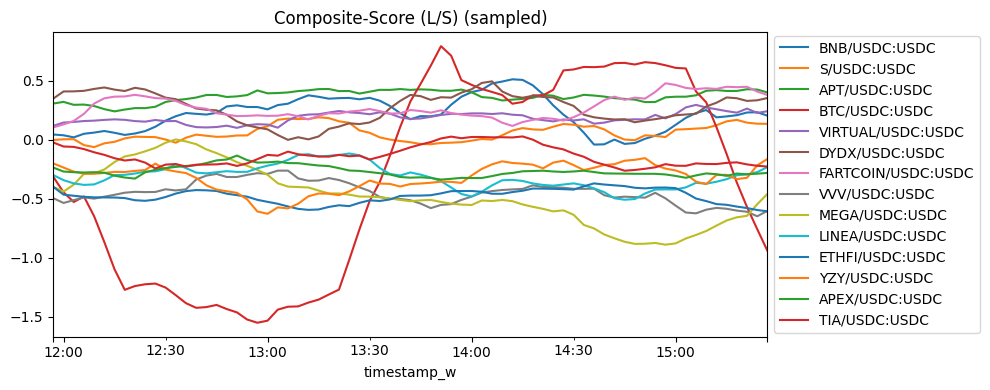

In [116]:
ax = composite_df[fixed_sampling_token].rolling(window=10).mean().dropna().plot(figsize=(10, 4))

# Put legend outside
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.title('Composite-Score (L/S) (sampled)')
plt.tight_layout()
plt.show()

In [117]:
print(ideas_arr[-1].keys())
print()
print('Top10%-Long: ', ideas_arr[-1]['longs'])
print('Bottom10%-Short: ', ideas_arr[-1]['shorts'])
print()
pprint(ideas_arr[-1])

dict_keys(['timestamp', 'data_timestamp', 'longs', 'shorts', 'long_scores', 'short_scores'])

Top10%-Long:  ['BNB/USDC:USDC', 'S/USDC:USDC', 'APT/USDC:USDC', 'BTC/USDC:USDC', 'VIRTUAL/USDC:USDC', 'DYDX/USDC:USDC', 'FARTCOIN/USDC:USDC']
Bottom10%-Short:  ['VVV/USDC:USDC', 'MEGA/USDC:USDC', 'LINEA/USDC:USDC', 'ETHFI/USDC:USDC', 'YZY/USDC:USDC', 'APEX/USDC:USDC', 'TIA/USDC:USDC']

{'data_timestamp': Timestamp('2025-12-06 15:00:00+0000', tz='UTC'),
 'long_scores': [1.0, 0.975, 0.949, 0.924, 0.899, 0.873, 0.848],
 'longs': ['BNB/USDC:USDC',
           'S/USDC:USDC',
           'APT/USDC:USDC',
           'BTC/USDC:USDC',
           'VIRTUAL/USDC:USDC',
           'DYDX/USDC:USDC',
           'FARTCOIN/USDC:USDC'],
 'short_scores': [-0.975, -0.949, -0.924, -0.899, -0.873, -0.848, -0.823],
 'shorts': ['VVV/USDC:USDC',
            'MEGA/USDC:USDC',
            'LINEA/USDC:USDC',
            'ETHFI/USDC:USDC',
            'YZY/USDC:USDC',
            'APEX/USDC:USDC',
            'TIA/USDC:USDC

#### LLM-Based Integration (*Filtering) + Market(Dollar) Neutrality

In [118]:
%pip install -q -U google-genai duckduckgo-search


[notice] A new release of pip is available: 24.0 -> 25.3


Note: you may need to restart the kernel to use updated packages.

[notice] To update, run: python.exe -m pip install --upgrade pip

In [157]:
import os
import time
import json
from google import  genai
from duckduckgo_search import DDGS
import dotenv
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

dotenv.load_dotenv('src/keys/.env')

True

In [120]:
GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')

In [121]:
class NewsFilterAgent:
    def __init__(self, api_key, model_name='gemini-1.5-flash'):
        """
        Args:
            api_key: Your Google Gemini API Key
        """
        # genai.configure(api_key=api_key)
        self.model_name = model_name
        self.client = genai.Client()
        self.ddgs = DDGS()

    def get_news_snippets(self, symbol, lookback_hours=24):
        """Searches DuckDuckGo for recent news."""
        query = f"{symbol} crypto token news hack exploit delisting unlock"
        try:
            # DDG returns a list of dictionaries
            results = list(self.ddgs.news(keywords=query, max_results=5))
            if not results:
                return "No significant news found."
            
            # Combine titles and snippets
            context = "\n".join([f"- {r['title']}: {r['body']}" for r in results])
            return context
        except Exception as e:
            return f"Error fetching news: {str(e)}"

    def vet_asset(self, symbol):
        """
        Returns: (bool, reason) -> (True if CLEAN, False if WARNING)
        """
        news_context = self.get_news_snippets(symbol)
        
        # If search failed or empty, default to Safe to avoid over-filtering
        if "Error" in news_context or "No significant news" in news_context:
            return True, "No News"

        prompt = f"""
        You are a Risk Manager for a crypto hedge fund. 
        Analyze the following news headlines for the asset '{symbol}'.
        
        Task: Flag if there is HIGH RISK news from the last 24 hours.
        High Risk Definitions:
        1. Hacks / Exploits / Security Breaches.
        2. Delisting announcements from major exchanges (Binance, Coinbase).
        3. Massive Token Unlocks or Foundation selling.
        4. SEC lawsuits or Regulatory bans.

        Ignore: Price prediction, standard volatility, partnership announcements, shills.

        News Context:
        {news_context}

        Output Format (JSON only, don't write json):
        {{"status": "CLEAN" or "WARNING", "reason": "Short explanation"}}
        """

        try:
            response = self.client.models.generate_content(model = self.model_name, contents = prompt)
            result = json.loads(response.text)
            
            is_clean = result.get("status") == "CLEAN"
            return is_clean, result.get("reason")
            
        except Exception as e:
            print(f"LLM Error on {symbol}: {e}")
            return True, "LLM Error" # Fail open (allow trade) or closed (block trade) based on preference

In [122]:
# test_symbol = 'BTC'
test_symbol = 'AVAX'

In [123]:
news_filter = NewsFilterAgent(GOOGLE_API_KEY, model_name='gemini-2.5-flash')
news = news_filter.get_news_snippets(test_symbol)
news_ans = news_filter.vet_asset(test_symbol)

C:\Users\Alik\AppData\Local\Temp\ipykernel_30672\3479602810.py:10: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  self.ddgs = DDGS()


LLM Error on AVAX: Expecting value: line 1 column 1 (char 0)


In [124]:
print(news_ans)

(True, 'LLM Error')


Some Ideation of LLM integration > <mark>1. Trade Filtering based on (LLM-based + API) information retrieval service</mark>. 2. Better Information based LLM parsingg/reasoning 3. Sector wise news retrieval + reasoning

Input: The Ticker Symbols of your Top 5.
Search: Hook up a search tool (SerpAPI / Google) or a crypto news API (CryptoPanic).
Prompt:
"I am considering a momentum Long trade on these 5 assets: [List]. Search for significant news in the last 24 hours. Flag any assets that are moving due to: 1. Hacks/Exploits, 2. Delisting fears, 3. Token Unlocks. Output: 'CLEAN' or 'WARNING: [Reason]'."

#### Backtest/Last-4hr (Only L2 mOB data)/reduce the trade-horizon to 3 minutes

How do I create a freeLLM-model integration? (semi-large? 10B parameter model + API-call latency)

In [ ]:
def backtest_ob_llm(
    strategy_output,   # The dictionary returned from your previous function
    price_df,          # DataFrame with 'close' prices (MultiIndex or pivoted)
    llm_agent=None,    # Instance of NewsFilterAgent
    capital=10000,
    check_longs=True,  # Vet Longs for hacks?
    check_shorts=False # Vet Shorts for buyouts? (Usually less critical for momemtum)
    ):
    
    ideas = strategy_output['ideas']
    
    equity_curve = []
    trade_log = []
    current_capital = capital
    
    print(f"--- Starting Backtest on {len(ideas)} rebalance periods ---")
    
    for i, signal in enumerate(ideas):
        timestamp = signal['timestamp']
        
        raw_longs = signal['longs']
        raw_shorts = signal['shorts']
        
        # LLM Filtering (The Quantamental Layer)
        final_longs = []
        final_shorts = []
        
        if llm_agent: ## using search-engine searches are sub-optimal because it always skews the retrieved information based on the keyword pased >> need to do temporal-filtering
            print(f"[{timestamp}] Vetting {len(raw_longs)} Long candidates...")
            for asset in raw_longs:
                # Time-Travel Warning: This checks CURRENT news, not historical news
                is_clean, reason = llm_agent.vet_asset(asset)
                
                if is_clean:
                    final_longs.append(asset)
                else:
                    print(f"  >>> REJECTED {asset}: {reason}")
                    trade_log.append({
                        "timestamp": timestamp, "type": "REJECTED", 
                        "asset": asset, "reason": reason
                    })
            print()
            print(f"[{timestamp}] Vetting {len(raw_shorts)} Short candidates...")
            for asset in raw_shorts:
                # Time-Travel Warning: This checks CURRENT news, not historical news
                is_clean, reason = llm_agent.vet_asset(asset)
                
                if is_clean:
                    final_shorts.append(asset)
                else:
                    print(f"  >>> REJECTED {asset}: {reason}")
                    trade_log.append({
                        "timestamp": timestamp, "type": "REJECTED", 
                        "asset": asset, "reason": reason
                    })
                    
        else:
            final_longs = raw_longs # No LLM provided
            final_shorts = raw_shorts

        if not final_longs and not final_shorts:
            equity_curve.append({"timestamp": timestamp, "equity": current_capital})
            continue

        # Split capital 50/50 Long/Short (Market Neutral-ish) >> Dollar-neutral
        long_alloc = current_capital * 0.5 if final_longs else 0
        short_alloc = current_capital * 0.5 if final_shorts else 0
        
        # Capital per asset
        amt_per_long = long_alloc / len(final_longs) if final_longs else 0
        amt_per_short = short_alloc / len(final_shorts) if final_shorts else 0
        
        if i + 1 >= len(ideas):
            break # Cannot calculate return for the very last step
            
        next_timestamp = ideas[i+1]['timestamp']
        
        def get_price(ts, asset):
            try:
                if isinstance(price_df.index, pd.MultiIndex):
                    return price_df.loc[(asset, ts)]['close'] 
                else:
                    # If pivoted (Time index, Asset columns)
                    return price_df.loc[ts][asset]
            except:
                return np.nan

        period_pnl = 0
        
        # Calc Long Returns
        asset_cap = 3
        
        for asset in final_longs[:asset_cap]:
            p_entry = get_price(timestamp, asset)
            p_exit = get_price(next_timestamp, asset)
            
            if pd.isna(p_entry) or pd.isna(p_exit): continue
            
            ret = (p_exit - p_entry) / p_entry
            period_pnl += amt_per_long * ret
            
        # Calc Short Returns
        for asset in final_shorts[:asset_cap]:
            p_entry = get_price(timestamp, asset)
            p_exit = get_price(next_timestamp, asset)
            
            if pd.isna(p_entry) or pd.isna(p_exit): continue
            
            ret = (p_entry - p_exit) / p_entry # Short return
            period_pnl += amt_per_short * ret
            
        current_capital += period_pnl
        equity_curve.append({"timestamp": next_timestamp, "equity": current_capital})
        
        # Logging
        trade_log.append({
            "timestamp": timestamp,
            "type": "EXECUTION",
            "longs": final_longs,
            "shorts": final_shorts,
            "pnl": period_pnl
        })

    return pd.DataFrame(equity_curve), pd.DataFrame(trade_log)

In [147]:
df_local_3min = df_multi_token_3min.groupby(level='token').tail(80)

In [158]:
agent = NewsFilterAgent(api_key=GOOGLE_API_KEY)

C:\Users\Alik\AppData\Local\Temp\ipykernel_30672\3479602810.py:10: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  self.ddgs = DDGS()


--- Starting Backtest on 8 rebalance periods ---
Final Equity: 10010.427271745737


<Figure size 1200x300 with 0 Axes>

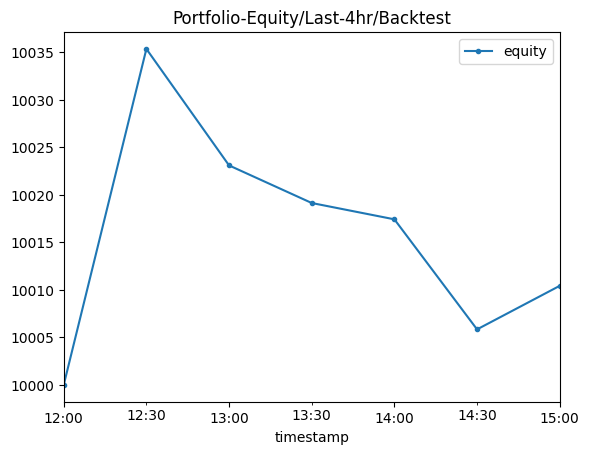

In [ ]:
# Run Backtest
# Note: For the last 4 hours, this will actually perform REAL searches. // LookAhead-Leakage
equity_df, log_df = backtest_ob_llm(
    strategy_output=score_dict,
    price_df=df_local_3min, # Needs to contain 'close' prices
    llm_agent=None,
    capital=10000
)

equity_df, log_df = equity_df.set_index('timestamp'), log_df.set_index('timestamp')

# Analyze Results
print("Final Equity:", equity_df.iloc[-1]['equity'])

plt.figure(figsize=(12, 3))

equity_df.plot(marker='.')

plt.title('Portfolio-Equity/Last-4hr/Backtest')
plt.show()

# # Check what the LLM rejected
# rejected = log_df[log_df['type'] == 'REJECTED']
# print("\n--- LLM Rejections ---")
# print(rejected[['timestamp', 'asset', 'reason']])

Better to Forward-Test / Discretionary